# Problem 1
## Dataset Generation

Write a function to **generate a training set** of size $m$
- randomly generate a weight vector $w \in \mathbb{R}^{10}$, normalize length
- generate a training set $\{(x_i , y_i)\}$ of size m
  - $x_i$: random vector in $\mathbb{R}^{10}$ from $\textbf{N}(0, I)$
  - $y_i$: $\{0, +1\}$ with $P[y = +1] = \sigma(w \cdot x_i)$ and $P[y = 0] = 1 - \sigma(w \cdot x_i)$

In [1]:
from typing import Tuple, Callable

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def sigmoid(x: np.ndarray) -> np.ndarray:
    """
    Sigmoid function.
    """
    return 1 / (1 + np.exp(x))


def generate_data(m, seed=None) -> Tuple[np.ndarray, np.ndarray, int]:
    """
    Returns (w_star, X, y).
    """
    # set the seed
    np.random.seed(seed)

    # generate w
    w_star = np.random.randn(10)
    w_star = w_star / np.linalg.norm(w_star, ord=2)

    # generate x
    X = np.random.randn(m, 10)

    # generate y
    y = np.random.binomial(1, sigmoid(X @ w_star))

    return w_star, X, y


def create_pairplot(X, y):
    """
    Create a pairplot of the data.
    """
    # Convert the numpy arrays to a DataFrame
    df = pd.DataFrame(X, columns=[f'Feature {i+1}' for i in range(X.shape[1])])
    df['Label'] = y

    # Create the pairplot
    sns.pairplot(df, hue='Label', plot_kws={'alpha': 0.5, 's': 10})
    plt.show()


# generate data
w_star, X, y = generate_data(m=1000, seed=None)

# print shape of w_init, x, and y with left justification
print(f"Shape of w_star:".ljust(20) + f"{w_star.shape}")
print(f"Shape of X:".ljust(20) + f"{X.shape}")
print(f"Shape of y:".ljust(20) + f"{y.shape}")

# inspect data 
# create_pairplot(X, y)

Shape of w_star:    (10,)
Shape of X:         (1000, 10)
Shape of y:         (1000,)


## Algorithm 1: logistic regression

The goal is to learn $w$.  Algorithm 1 is logistic
  regression (you may use the built-in method LogisticRegression for this. Use max_iter=1000).

In [2]:
from sklearn.linear_model import LogisticRegression

ITERATIONS = 1000


def logistic_regression(X: np.ndarray, y: np.ndarray, T=ITERATIONS) -> np.ndarray:
    """
    Returns the weights of the logistic regression model
    """
    model = LogisticRegression(max_iter=T)
    model.fit(X, y)
    return model.coef_


# train
w_hat_lg = logistic_regression(X, y)
print(f"w_hat_lg: {w_hat_lg}")

w_hat_lg: [[ 0.13300785 -0.14866884  0.02253278 -0.2910551  -0.42377795  0.51173079
   0.056757    0.14467072 -0.35812004  0.22865233]]


## Algorithm 2: gradient descent with square loss

Define square loss as
$$L_i(w^{(t)}) = \frac{1}{2} \left( \sigma(w^{(t)} \cdot x) - y_i \right)^2$$

  Algorithm 2 is
  gradient descent with respect to square loss (code this
  up yourself -- run for 1000 iterations, use step size eta = 0.01).

In [4]:
ETA = 0.01


def grad_single(x: np.ndarray, y: np.ndarray, w_t: np.ndarray) -> np.ndarray:
    """
    Calculate gradient for a single x vector. This will be used in 
    stochastic gradient descent.
    """
    # sigmoid(w^t @ x) represents the prediction at x, i.e. the probability y=1
    pred = sigmoid(w_t@x)

    # calculated by hand and verified with other sources
    return (pred - y) * pred * (1 - pred) * x


# def grad_loop(X: np.ndarray, y: np.ndarray, w_t: np.ndarray) -> np.ndarray:
#     """
#     Calculate gradient in a loop for understanding. I'll replace this with
#     matrix operations later.
#     """
#     # keep track of cumulative gradient for averaging
#     grad_accum = np.zeros_like(w_t)

#     # loop through each x vector (training example) in X
#     for i, x_i in enumerate(X):
#         # calculate gradient for x_i and accumulate
#         grad = grad_single(x_i, y[i], w_t)
#         grad_accum += grad

#     # return average grad
#     return grad_accum / (i + 1)


def grad_matrices(X: np.ndarray, y: np.ndarray, w_t: np.ndarray) -> np.ndarray:
    """
    Calculate gradient using matrix operations. Should get the same result as
    when using grad_loop. Getting back into thinking in matrices, this took
    a while to think through.
    """
    pred = sigmoid(X@w_t)
    return X.T @ ((pred - y) * pred * (1 - pred)) / len(X)


def batch_gradient_descent(
    X: np.ndarray,
    y: np.ndarray,
    T: int = ITERATIONS,
    eta: float = ETA,
) -> np.ndarray:
    """
    Perform gradient descent to estimate the weight vector. Do this in a loop
    first for understanding
    """
    # initialize w_t to same dimension as X
    w_t = np.zeros_like(X[0])

    # loop through T iterations
    for _ in range(T):
        w_t = w_t - eta * grad_matrices(X, y, w_t)
    return w_t


# train
w_hat_bgd = batch_gradient_descent(X=X, y=y)
print(f"w_hat_bgd: {w_hat_bgd}")

w_hat_bgd: [ 0.09325305 -0.13267378  0.01485623 -0.1984804  -0.31271832  0.32676259
  0.06378322  0.09975788 -0.22839983  0.16034283]


## Algorithm 3: stochastic gradient descent with square loss
Similar to gradient descent, except we use the gradient at a single random training point every iteration.

In [5]:
def stochastic_gradient_descent(X: np.ndarray, y: np.ndarray, T: int=ITERATIONS, eta: float=ETA) -> np.ndarray:
    """
    Perform stochastic gradient descent to estimate the weight vector.
    """
    # initialize w_t to same dimension as X
    w_t = np.zeros_like(X[0])

    # loop through T iterations
    for _ in range(T):
        # sample a random vector from X
        i = np.random.randint(len(X))
        x_i = X[i]

        # calculate gradient for x_i and accumulate
        grad = grad_single(x_i, y[i], w_t)
        w_t = w_t - eta * grad

    return w_t

# train
w_hat_sgd = stochastic_gradient_descent(X=X, y=y)
print(f"w_hat_sgd: {w_hat_sgd}")

w_hat_sgd: [ 0.08511038 -0.16848959  0.06049057 -0.3127744  -0.20206512  0.31523915
  0.07067799  0.093268   -0.24814616  0.10714517]


## Evaluation

Measure error $\|w - \hat{w}\|_2$ for each method at different sample size. For any
  fixed value of $m$, choose many different $w$'s and average the
  values $\|w - 
  \hat{w}\|_2$ for Algorithms 1, 2 and 3.  Plot the results
  for for each algorithm as you make $m$ large (use $m=50, 100, 150, 200, 250$).
  Also record, for each algorithm, the time taken to run the overall experiment.

model
logistic_regression            0.038989
stochastic_gradient_descent    0.226645
batch_gradient_descent         0.408970
Name: time, dtype: float64

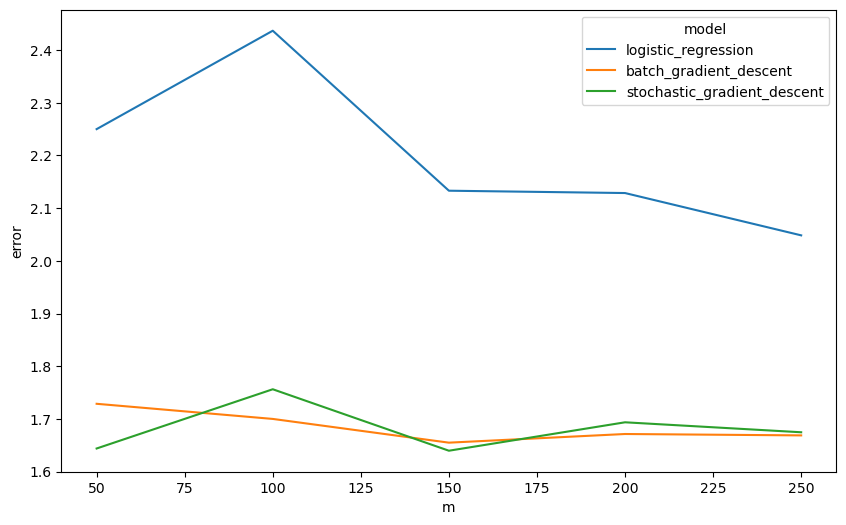

In [36]:
import time
from functools import wraps


def timeit(func):
    @wraps(func)
    def wrapper(*args, **kwargs):
        start_time = time.time()
        result = func(*args, **kwargs)
        end_time = time.time()
        time_taken = end_time - start_time
        return result, time_taken
    return wrapper


def weight_vector_error(w_star: np.ndarray, w_hat: np.ndarray) -> float:
    """
    Returns the error between the true weights and the estimated weights

    Args:
        w_star: the true weights
        w_hat: the estimated weights

    Returns:
        float: the error
    """
    return np.linalg.norm(w_star - w_hat, ord=2)


def run_single_trial(model: Callable, m: int, seed=None, **kwargs) -> float:
    """
    Run a single trial of the experiment.

    Args:
        model: the model to train
        m: number of training examples
        **kwargs: additional arguments to pass to the model

    Returns:
        float: the error for single trial of sample size m
    """
    w_star, X, y = generate_data(m, seed)
    w_hat = model(X, y, **kwargs)
    return weight_vector_error(w_star, w_hat)

@timeit
def run_n_trials(model: Callable, n: int, m: int, seed=None, **kwargs) -> float:
    """
    Run n trials of the experiment and return the average error.

    Args:
        model: the model to train
        n: number of trials
        m: number of training examples
        **kwargs: additional arguments to pass to the model

    Returns:
        float: the average error over n trials
    """
    # run n trials
    seed_ = lambda i: seed if seed is None else seed + i
    errors = [run_single_trial(model, m, seed_(i), **kwargs) for i in range(n)]
    return np.mean(errors)


def run_experiment(ms: list[int], n: int, seed=None, T=ITERATIONS, eta=ETA) -> dict:
    """
    Run the experiment for each model and return the results.

    Args:
        n: number of trials
        m: number of training examples

    Returns:
        dict: the results
    """
    results = []

    for m in ms:
        # logistic regression
        error, time = run_n_trials(logistic_regression, n, m, seed)
        results.append(
            {'model': 'logistic_regression', 'm': m, 'error': error, 'time': time})

        # batch gradient descent
        error, time = run_n_trials(batch_gradient_descent, n, m, seed)
        results.append(
            {'model': 'batch_gradient_descent', 'm': m, 'error': error, 'time': time})

        # stochastic gradient descent
        error, time = run_n_trials(
            stochastic_gradient_descent, n, m, seed)
        results.append(
            {'model': 'stochastic_gradient_descent', 'm': m, 'error': error, 'time': time})

    return results

n = 10 # number of trials to average over
ms = [50, 100, 150, 200, 250] # samlpe sizes to iterate over
results_pd = pd.DataFrame(run_experiment(ms, n=10, seed=None))

# group by model and display total time taken
display(results_pd.groupby('model').sum()['time'].sort_values(ascending=True))

# plot the results
plt.figure(figsize=(10, 6))
sns.lineplot(data=results_pd, x='m', y='error', hue='model')
plt.show()

# Problem 2

For each depth in $1, \dots, 5$, instantiate an AdaBoost classifier with the base learner set to be a decision tree of that depth (set `n_estimators=10` and `learning_rate=1`), and then record the 10-fold cross-validated error on the entire breast cancer data set. Plot the resulting curve of accuracy against base classifier depth. Use $101$ as your random state for both the base learner as well as the AdaBoost classifier every time.

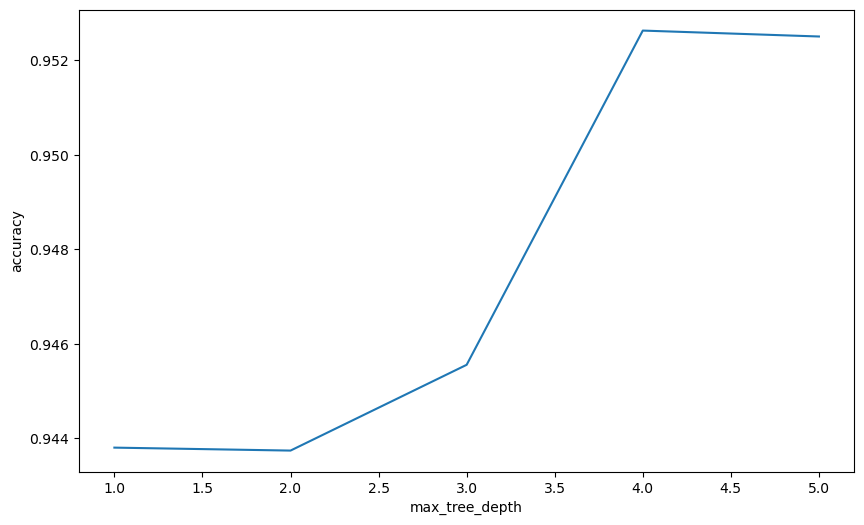

In [45]:
import warnings

from sklearn import datasets
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold, cross_val_score

warnings.filterwarnings('ignore', category=FutureWarning)

cancer = datasets.load_breast_cancer()


def fit_adaboost(X: np.ndarray, y: np.ndarray, max_tree_depth: int, n_estimators=10) -> float:
    """
    Fit an AdaBoost classifier using a decision tree as the base classifier
    """
    clf = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=max_tree_depth),
        n_estimators=n_estimators
    )
    kf = KFold(n_splits=10, shuffle=True)
    accuracy = cross_val_score(clf, X, y, cv=kf).mean()
    return accuracy


def run_adaboost_experiment(X: np.ndarray, y: np.ndarray, max_tree_depth: int):
    """
    Run the AdaBoost experiment
    """
    results = []
    for max_tree_depth in range(1, max_tree_depth + 1):
        accuracy = fit_adaboost(X, y, max_tree_depth)
        results.append({'max_tree_depth': max_tree_depth, 'accuracy': accuracy})
    return results


results_adaboost = pd.DataFrame(run_adaboost_experiment(cancer.data, cancer.target, 5))

plt.figure(figsize=(10, 6))
sns.lineplot(data=results_adaboost, x='max_tree_depth', y='accuracy')
plt.show()